# Entrega 3 — Execução do Design de Experimentos (DoE)
## Mineração de Dados · CRISP-DM: Modelagem e Avaliação

Este notebook **executa** o Design de Experimentos planejado na Entrega 3, sobre os
conjuntos de treino e teste transformados na Entrega 2
(`drug_events_train_transformed.csv` / `drug_events_test_transformed.csv`).

A hierarquia de execução segue o enunciado:

> **Features → Modelo → Hiperparâmetros → Métricas de Avaliação**

**Ordem desta execução (conforme solicitado):** esta etapa cobre apenas os **modelos de
árvore** (Random Forest e Gradient Boosting). A **Regressão Logística** (EXP-01/EXP-04)
fica **adiada para uma etapa posterior** e está apenas **documentada** ao final
(Seção 10), junto com a questão *saída categórica × saída contínua*.

| ID | Conjunto de Features | Modelo | Busca de Hiperparâmetros | Nesta execução |
|----|----------------------|--------|--------------------------|----------------|
| EXP-01 | Baseline (11) | Regressão Logística | GridSearchCV | adiado |
| **EXP-02** | **Baseline (11)** | **Random Forest** | **RandomizedSearchCV** | **✔** |
| **EXP-03** | **Baseline (11)** | **Gradient Boosting** | **RandomizedSearchCV** | **✔** |
| EXP-04 | Completo (17) | Regressão Logística | GridSearchCV | adiado |
| **EXP-05** | **Completo (17)** | **Random Forest** | **RandomizedSearchCV** | **✔** |
| **EXP-06** | **Completo (17)** | **Gradient Boosting** | **RandomizedSearchCV** | **✔** |

Reprodutibilidade garantida com `random_state=42` em todas as etapas estocásticas.


## 0. Configuração e imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, GridSearchCV, train_test_split,
)
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# --------------------------------------------------------------------------
# MODO_RAPIDO reduz o n_iter das buscas aleatórias (para demonstração/aula).
# A GRADE de hiperparâmetros é SEMPRE a do PDF (Tabela 1); apenas a quantidade
# de amostras sorteadas pelo RandomizedSearchCV muda.
# Para a execução final, defina MODO_RAPIDO = False.
# --------------------------------------------------------------------------
MODO_RAPIDO = True
print("MODO_RAPIDO =", MODO_RAPIDO)
print("Versões -> sklearn carregado, numpy", np.__version__, "| pandas", pd.__version__)

MODO_RAPIDO = True
Versões -> sklearn carregado, numpy 2.4.4 | pandas 3.0.2


## 1. Carregamento dos dados transformados (Entrega 2)

O notebook procura os arquivos transformados em locais comuns (`outputs/`, diretório
atual, etc.). **Caso eles não sejam encontrados**, um conjunto **sintético de
demonstração** com o *mesmo esquema de colunas* é gerado, apenas para permitir que o
notebook rode de ponta a ponta. Um aviso destacado indica qual fonte está em uso.

> Para resultados reais, basta colocar os CSVs da Entrega 2 em uma pasta `outputs/`
> ao lado deste notebook e reexecutar todas as células.


In [2]:
TARGET = "serious"
ID_COLS = ["Unnamed: 0", "safetyreportid"]

COLUNAS_TRANSFORMADAS = [
    "safetyreportid", "serious", "occurcountry",
    "patient.drug.activesubstance.activesubstancename",
    "patient.drug.drugcharacterization",
    "patient.drug.medicinalproduct",
    "patient.drug.count", "patient.patientsex",
    "patient.ageGroupCalculated",
    "patient.ageGroupCalculated_was_imputed",
    "feature_n_active_substances", "feature_n_drug_types",
    "feature_has_medicinal_product", "feature_multiple_drugs",
    "feature_is_usa",
]

def _localizar_csv(nome):
    candidatos = [
        Path.cwd() / "outputs" / nome,
        (Path.cwd().parent / "outputs" / nome),
        Path.cwd() / nome,
        Path("/mnt/project/outputs") / nome,
        Path("/mnt/user-data/uploads") / nome,
    ]
    for c in candidatos:
        if c.exists():
            return c
    return None


def _gerar_dados_sinteticos(n_total=3000, seed=RANDOM_STATE):
    '''Gera dados com o MESMO esquema da Entrega 2 e um sinal aprendível.
    A proporção da classe positiva é calibrada para ~62,3% (como no enunciado).'''
    rng = np.random.default_rng(seed)
    faixas = ["baby_early_childhood", "child", "adolescent",
              "young_adult", "adult", "elderly"]
    p_faixa = [0.03, 0.05, 0.05, 0.17, 0.40, 0.30]
    paises = ["US", "GB", "DE", "FR", "JP", "CA", "IT", "ES", "BR", "AU"]
    p_pais = [0.45, 0.12, 0.10, 0.08, 0.06, 0.05, 0.04, 0.04, 0.03, 0.03]
    substancias = np.array(["ASPIRIN", "IBUPROFEN", "PARACETAMOL", "METFORMIN",
        "ATORVASTATIN", "OMEPRAZOLE", "AMOXICILLIN", "WARFARIN", "INSULIN",
        "PREDNISONE", "LISINOPRIL", "SIMVASTATIN", "LEVOTHYROXINE", "TRAMADOL"])
    produtos = np.array(["TYLENOL", "ADVIL", "LIPITOR", "GLUCOPHAGE", "COUMADIN",
        "PRILOSEC", "NEURONTIN", "SYNTHROID", "HUMIRA", "ENBREL", "UNKNOWN"])

    faixa = rng.choice(faixas, size=n_total, p=p_faixa)
    pais = rng.choice(paises, size=n_total, p=p_pais)
    sexo = rng.choice(["male", "female", "unknown"], size=n_total, p=[0.45, 0.50, 0.05])
    n_subst = rng.integers(1, 5, size=n_total)
    n_tipos = rng.integers(1, 4, size=n_total)
    drug_count = n_subst + rng.integers(0, 3, size=n_total)
    was_imputed = rng.choice([0, 1], size=n_total, p=[0.8, 0.2])

    def join_sample(pool, k):
        k = int(min(k, len(pool)))
        idx = rng.choice(len(pool), size=k, replace=False)
        return " | ".join(sorted(pool[i] for i in idx))

    active = [join_sample(substancias, k) for k in n_subst]
    medic = [join_sample(produtos, int(rng.integers(1, 3))) for _ in range(n_total)]

    risco_faixa_map = {"baby_early_childhood": 0.3, "child": -0.2, "adolescent": -0.3,
                       "young_adult": -0.1, "adult": 0.1, "elderly": 0.8}
    risco_faixa = np.array([risco_faixa_map[f] for f in faixa])
    risco_pais = np.where(pais == "US", 0.2, 0.0)
    z0 = (risco_faixa + 0.35 * (n_subst - 2) + 0.22 * (n_tipos - 1)
          + 0.45 * (drug_count > 3).astype(float) + risco_pais)
    z = z0 + rng.normal(0, 0.55, size=n_total)

    # calibra o intercepto para ~62,3% de positivos
    alvo, lo, hi = 0.623, -6.0, 6.0
    for _ in range(60):
        mid = (lo + hi) / 2
        taxa = np.mean(1.0 / (1.0 + np.exp(-(z + mid))))
        lo, hi = (mid, hi) if taxa < alvo else (lo, mid)
    p = 1.0 / (1.0 + np.exp(-(z + (lo + hi) / 2)))
    serious = (rng.random(n_total) < p).astype(int)

    df = pd.DataFrame({
        "safetyreportid": [f"SYN{100000 + i}" for i in range(n_total)],
        "serious": serious,
        "occurcountry": pais,
        "patient.drug.activesubstance.activesubstancename": active,
        "patient.drug.drugcharacterization": ["1 | 2"] * n_total,
        "patient.drug.medicinalproduct": medic,
        "patient.drug.count": drug_count.astype(float),
        "patient.patientsex": sexo,
        "patient.ageGroupCalculated": faixa,
        "patient.ageGroupCalculated_was_imputed": was_imputed,
        "feature_n_active_substances": n_subst.astype(float),
        "feature_n_drug_types": n_tipos.astype(float),
        "feature_has_medicinal_product": (np.array(medic) != "UNKNOWN").astype(int),
        "feature_multiple_drugs": (drug_count > 1).astype(int),
        "feature_is_usa": (pais == "US").astype(int),
    })
    # padroniza numéricas, como na Entrega 2 (StandardScaler ajustado no treino)
    num = ["patient.drug.count", "feature_n_active_substances", "feature_n_drug_types"]
    tr, te = train_test_split(df, test_size=0.30, random_state=seed,
                              stratify=df["serious"])
    media, desvio = tr[num].mean(), tr[num].std(ddof=0)
    tr.loc[:, num] = (tr[num] - media) / desvio
    te.loc[:, num] = (te[num] - media) / desvio
    return tr.reset_index(drop=True), te.reset_index(drop=True)


train_path = _localizar_csv("drug_events_train_transformed.csv")
test_path = _localizar_csv("drug_events_test_transformed.csv")

if train_path and test_path:
    FONTE = "REAL"
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
else:
    FONTE = "SINTÉTICO"
    train_df, test_df = _gerar_dados_sinteticos()

# limpeza padrão
for _df in (train_df, test_df):
    _df.drop(columns=[c for c in ID_COLS if c in _df.columns], inplace=True, errors="ignore")
    _df.drop(columns=[c for c in _df.columns if c.startswith("Unnamed")],
             inplace=True, errors="ignore")
    _df[TARGET] = _df[TARGET].astype(int)
    for c in ["patient.drug.activesubstance.activesubstancename",
              "patient.drug.medicinalproduct"]:
        if c in _df.columns:
            _df[c] = _df[c].fillna("unknown").astype(str)

print(train_df.shape, test_df.shape)

(22616, 14) (9693, 14)


In [3]:
# Banner de origem dos dados + verificação da distribuição da classe alvo
prop = train_df[TARGET].value_counts(normalize=True).sort_index()
linha = "=" * 78
print(linha)
if FONTE == "REAL":
    print("  FONTE DOS DADOS: ARQUIVOS REAIS DA ENTREGA 2")
else:
    print("  ⚠️  FONTE DOS DADOS: CONJUNTO SINTÉTICO DE DEMONSTRAÇÃO  ⚠️")
    print("  Os CSVs transformados não foram encontrados. Os números abaixo")
    print("  servem APENAS para validar a execução do pipeline. Coloque os")
    print("  arquivos da Entrega 2 em 'outputs/' e reexecute para os resultados reais.")
print(linha)
print(f"  Treino: {len(train_df):>6} registros | Teste: {len(test_df):>6} registros")
print(f"  Distribuição de '{TARGET}' no treino:")
for k, v in prop.items():
    print(f"      classe {k}: {v:6.2%}")
print(linha)

resumo = pd.DataFrame({
    "conjunto": ["treino", "teste"],
    "registros": [len(train_df), len(test_df)],
    "atributos": [train_df.shape[1], test_df.shape[1]],
    "%_serious=1": [train_df[TARGET].mean(), test_df[TARGET].mean()],
})
resumo

  FONTE DOS DADOS: ARQUIVOS REAIS DA ENTREGA 2
  Treino:  22616 registros | Teste:   9693 registros
  Distribuição de 'serious' no treino:
      classe 1: 62.30%
      classe 2: 37.70%


,conjunto,registros,atributos,%_serious=1
0,treino,22616,14,1.377034
1,teste,9693,14,1.376973


## 2. Definição dos conjuntos de features (Atributos)

Para medir o impacto da **engenharia de atributos**, comparamos dois conjuntos:

**Conjunto A — Baseline (≈ 11 atributos):** estado dos dados *antes* da engenharia
de atributos — apenas as variáveis originais mantidas após limpeza e codificação
inicial. A contagem de 11 do enunciado corresponde a estas colunas com a faixa etária
já expandida via *One-Hot Encoding*.

**Conjunto B — Completo (17 atributos):** estende o Baseline com as **5 features de
engenharia** (`feature_n_active_substances`, `feature_n_drug_types`,
`feature_has_medicinal_product`, `feature_multiple_drugs`, `feature_is_usa`) **+ 1
flag** da imputação por KNN (`patient.ageGroupCalculated_was_imputed`) → 11 + 6 = 17.

Os atributos textuais (`...activesubstancename`, `...medicinalproduct`) são
vetorizados por **TF-IDF** dentro do pipeline (sem vazamento, pois é ajustado em cada
*fold* do treino). A coluna `patient.drug.drugcharacterization` não entra como
atributo direto — ela já está resumida em `feature_n_drug_types`.


In [4]:
COL_NUMERICAS = ["patient.drug.count",
                 "feature_n_active_substances", "feature_n_drug_types"]
COL_CATEGORICAS = ["occurcountry", "patient.patientsex", "patient.ageGroupCalculated"]
COL_BINARIAS = ["patient.ageGroupCalculated_was_imputed",
                "feature_has_medicinal_product", "feature_multiple_drugs",
                "feature_is_usa"]
COL_TEXTO = ["patient.drug.activesubstance.activesubstancename",
             "patient.drug.medicinalproduct"]

FEATURES_ENGENHARIA = ["feature_n_active_substances", "feature_n_drug_types",
                       "feature_has_medicinal_product", "feature_multiple_drugs",
                       "feature_is_usa"]
FLAG_IMPUTACAO = "patient.ageGroupCalculated_was_imputed"

# Conjunto A (Baseline): atributos originais (antes da engenharia de atributos)
CONJUNTO_A = ["occurcountry", "patient.patientsex", "patient.ageGroupCalculated",
              "patient.drug.count",
              "patient.drug.activesubstance.activesubstancename",
              "patient.drug.medicinalproduct"]
# Conjunto B (Completo): A + 5 features de engenharia + flag de imputação
CONJUNTO_B = CONJUNTO_A + FEATURES_ENGENHARIA + [FLAG_IMPUTACAO]

feature_sets = {
    "A_baseline": {
        "rotulo": "Baseline (11)",
        "descricao": "Atributos originais antes da engenharia de atributos.",
        "colunas": [c for c in CONJUNTO_A if c in train_df.columns],
    },
    "B_completo": {
        "rotulo": "Completo (17)",
        "descricao": "Baseline + 5 features de engenharia + flag de imputação KNN.",
        "colunas": [c for c in CONJUNTO_B if c in train_df.columns],
    },
}

pd.DataFrame([
    {"conjunto": k, "rotulo": v["rotulo"], "n_colunas_dataframe": len(v["colunas"]),
     "descricao": v["descricao"]}
    for k, v in feature_sets.items()
])

,conjunto,rotulo,n_colunas_dataframe,descricao
0,A_baseline,Baseline (11),6,Atributos originais antes da engenharia de atr...
1,B_completo,Completo (17),12,Baseline + 5 features de engenharia + flag de ...


## 3. Pré-processamento (pipeline sem vazamento)

Cada tipo de coluna recebe um tratamento adequado, todo ele **ajustado dentro da
validação cruzada** (portanto sem vazamento treino→teste):

- **Numéricas:** imputação pela mediana + padronização (`StandardScaler`).
- **Categóricas:** imputação pela moda + `OneHotEncoder` (categorias raras agrupadas).
- **Binárias:** repassadas diretamente (`passthrough`).
- **Texto:** `TfidfVectorizer` (vetorização, conforme o PDF).

A saída é densa (`sparse_threshold=0.0`), exigência do `GradientBoostingClassifier`.


In [5]:
def construir_preprocessador(colunas):
    num = [c for c in COL_NUMERICAS if c in colunas]
    cat = [c for c in COL_CATEGORICAS if c in colunas]
    bina = [c for c in COL_BINARIAS if c in colunas]
    txt = [c for c in COL_TEXTO if c in colunas]

    transformers = []
    if num:
        transformers.append(("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num))
    if cat:
        transformers.append(("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                  min_frequency=10)),
        ]), cat))
    if bina:
        transformers.append(("bin", "passthrough", bina))
    for t in txt:
        nome = "txt_" + t.split(".")[-1]
        transformers.append((nome, TfidfVectorizer(max_features=120, min_df=5), t))

    return ColumnTransformer(transformers, remainder="drop", sparse_threshold=0.0)

# verificação rápida da dimensionalidade gerada por cada conjunto
for k, v in feature_sets.items():
    pp = construir_preprocessador(v["colunas"])
    n_feat = pp.fit_transform(train_df[v["colunas"]]).shape[1]
    print(f"{k:<12} -> {len(v['colunas'])} colunas de entrada "
          f"=> {n_feat} features após pré-processamento")

A_baseline   -> 6 colunas de entrada => 304 features após pré-processamento


B_completo   -> 12 colunas de entrada => 310 features após pré-processamento


## 4. Modelos de árvore e grades de hiperparâmetros (PDF — Tabela 1)

| Modelo | Hiperparâmetro | Valores |
|--------|----------------|---------|
| **Random Forest** (RandomizedSearchCV) | `n_estimators` | [100, 200, 300] |
| | `max_depth` | [10, 20, None] |
| | `min_samples_split` | [2, 5] |
| | `min_samples_leaf` | [1, 2] |
| | `class_weight` | ['balanced', None] |
| **Gradient Boosting** (RandomizedSearchCV) | `n_estimators` | [100, 200, 300] |
| | `learning_rate` | [0.01, 0.1, 0.2] |
| | `max_depth` | [3, 5, 7] |

O `class_weight` é testado para o Random Forest (mitiga o desbalanceamento). O
`GradientBoostingClassifier` não possui esse hiperparâmetro, conforme o próprio PDF.


In [6]:
# --------------------------------------------------------------------------
# MODO_RAPIDO = True  -> grades enxutas para a PRIMEIRA execução (rápida).
#   O custo do Gradient Boosting cresce com n_estimators e max_depth, então
#   no modo rápido ele fica limitado a árvores rasas e poucas.
# MODO_RAPIDO = False -> grades EXATAS do PDF (Tabela 1), para o run final.
# --------------------------------------------------------------------------
if MODO_RAPIDO:
    N_ITER_RF, N_ITER_GB = 6, 4
    grade_rf = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [10, None],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__class_weight": ["balanced", None],
    }
    grade_gb = {
        "model__n_estimators": [50, 100],
        "model__learning_rate": [0.1, 0.2],
        "model__max_depth": [3],
    }
else:
    N_ITER_RF, N_ITER_GB = 30, 20
    grade_rf = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [10, 20, None],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__class_weight": ["balanced", None],
    }
    grade_gb = {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.1, 0.2],
        "model__max_depth": [3, 5, 7],
    }

modelos_arvore = {
    "random_forest": {
        "nome": "Random Forest",
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        "param_dist": grade_rf,
        "n_iter": N_ITER_RF,
    },
    "gradient_boosting": {
        "nome": "Gradient Boosting",
        "estimator": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "param_dist": grade_gb,
        "n_iter": N_ITER_GB,
    },
}
print("Modo rápido:", MODO_RAPIDO, "| n_iter RF/GB:", N_ITER_RF, N_ITER_GB)
print("Modelos de árvore configurados:", list(modelos_arvore))

Modo rápido: True | n_iter RF/GB: 6 4
Modelos de árvore configurados: ['random_forest', 'gradient_boosting']


## 5. Estratégia de avaliação e métricas

**Validação cruzada:** `StratifiedKFold` com `cv=5` (preserva a proporção das classes).
**Métrica primária de seleção (refit):** `f1_macro` (avaliação justa entre as classes
sob desbalanceamento moderado).

### Saída categórica × saída contínua (ponto-chave)

Todo classificador produz **duas formas de saída**, e cada métrica usa a forma correta:

- **Saída CATEGÓRICA** — os rótulos previstos (`predict` → 0/1, com limiar 0,5).
  Usada em **Acurácia, Precisão, Recall, F1 e Matriz de Confusão**.
- **Saída CONTÍNUA** — a probabilidade da classe positiva (`predict_proba[:, 1]`).
  Usada na **ROC AUC**, que mede a separação entre classes em *todos* os limiares.

Isso vale igualmente para Random Forest, Gradient Boosting e Regressão Logística.
Reportamos as métricas em **treino e teste** para diagnosticar *overfitting*/*underfitting*.


In [7]:
# Em modo rápido usamos cv=3 (3 folds em vez de 5) para a primeira execução.
cv = StratifiedKFold(n_splits=3 if MODO_RAPIDO else 5,
                     shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",            # binária (classe positiva = serious=1)
    "recall": "recall",
    "f1": "f1",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc",                # usa a saída CONTÍNUA (probabilidade)
}
METRICA_PRIMARIA = "f1_macro"


def avaliar(estimator, X, y, conjunto):
    '''Calcula as métricas usando a forma de saída correta para cada uma.'''
    y_pred = estimator.predict(X)                  # saída CATEGÓRICA (rótulos)
    y_proba = estimator.predict_proba(X)[:, 1]     # saída CONTÍNUA (probabilidade)
    return {
        "conjunto": conjunto,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision_pos": precision_score(y, y_pred, pos_label=1, zero_division=0),
        "recall_pos": recall_score(y, y_pred, pos_label=1, zero_division=0),
        "f1_pos": f1_score(y, y_pred, pos_label=1, zero_division=0),
        "precision_macro": precision_score(y, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y, y_proba),
    }

# matrizes X/y
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET].astype(int)
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET].astype(int)
print("Estratégia de avaliação pronta. Métrica primária (refit):", METRICA_PRIMARIA)

Estratégia de avaliação pronta. Métrica primária (refit): f1_macro


## 6. Execução dos experimentos com modelos de árvore

Cada experimento é uma execução completa de `RandomizedSearchCV` (busca de
hiperparâmetros + validação cruzada estratificada de 5 *folds*) sobre um conjunto de
features específico. A seleção do melhor modelo usa `f1_macro`.


In [8]:
def executar_experimento(exp_id, feature_set_key, modelo_key):
    fs = feature_sets[feature_set_key]
    spec = modelos_arvore[modelo_key]
    cols = fs["colunas"]

    pipeline = Pipeline([
        ("preprocess", construir_preprocessador(cols)),
        ("model", spec["estimator"]),
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=spec["param_dist"],
        n_iter=spec["n_iter"],
        scoring=scoring,
        refit=METRICA_PRIMARIA,
        cv=cv,
        return_train_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
    )
    print(f"[{exp_id}] {fs['rotulo']:<14} | {spec['nome']:<18} "
          f"| RandomizedSearchCV (n_iter={spec['n_iter']}, "
          f"cv={cv.get_n_splits()}) ...", flush=True)
    search.fit(X_train[cols], y_train)

    bi = search.best_index_
    cvr = search.cv_results_
    melhor = search.best_estimator_

    reg = {
        "exp_id": exp_id,
        "conjunto": fs["rotulo"],
        "modelo": spec["nome"],
        "melhores_hiperparametros": {k.replace("model__", ""): v
                                     for k, v in search.best_params_.items()},
        "cv_f1_macro_mean": cvr["mean_test_f1_macro"][bi],
        "cv_f1_macro_std": cvr["std_test_f1_macro"][bi],
        "cv_roc_auc_mean": cvr["mean_test_roc_auc"][bi],
        "cv_roc_auc_std": cvr["std_test_roc_auc"][bi],
    }
    for nome_conj, X_, y_ in [("treino", X_train[cols], y_train),
                              ("teste", X_test[cols], y_test)]:
        m = avaliar(melhor, X_, y_, nome_conj)
        for chave, valor in m.items():
            if chave == "conjunto":
                continue
            reg[f"{nome_conj}_{chave}"] = valor

    reg["_estimator"] = melhor
    reg["_cm_teste"] = confusion_matrix(y_test, melhor.predict(X_test[cols]))
    # Guarda TODAS as configurações sorteadas pela busca (mapa hiperparâmetro -> resultado),
    # usado na Seção 9.4 para exportar os rankings completos por experimento.
    reg["_cv_results"] = search.cv_results_
    print(f"        -> melhor f1_macro (CV) = {reg['cv_f1_macro_mean']:.4f} "
          f"± {reg['cv_f1_macro_std']:.4f} | f1_macro (teste) = "
          f"{reg['teste_f1_macro']:.4f} | ROC AUC (teste) = {reg['teste_roc_auc']:.4f}")
    return reg

In [9]:
experimentos_arvore = [
    ("EXP-02", "A_baseline", "random_forest"),
    ("EXP-03", "A_baseline", "gradient_boosting"),
    ("EXP-05", "B_completo", "random_forest"),
    ("EXP-06", "B_completo", "gradient_boosting"),
]

resultados = [executar_experimento(eid, fkey, mkey)
              for eid, fkey, mkey in experimentos_arvore]
print("\nConcluído:", len(resultados), "experimentos de árvore.")

[EXP-02] Baseline (11)  | Random Forest      | RandomizedSearchCV (n_iter=6, cv=3) ...


        -> melhor f1_macro (CV) = 0.8104 ± 0.0042 | f1_macro (teste) = 0.8165 | ROC AUC (teste) = 0.9038
[EXP-03] Baseline (11)  | Gradient Boosting  | RandomizedSearchCV (n_iter=4, cv=3) ...


        -> melhor f1_macro (CV) = 0.8002 ± 0.0041 | f1_macro (teste) = 0.8057 | ROC AUC (teste) = 0.8989
[EXP-05] Completo (17)  | Random Forest      | RandomizedSearchCV (n_iter=6, cv=3) ...


        -> melhor f1_macro (CV) = 0.8193 ± 0.0046 | f1_macro (teste) = 0.8259 | ROC AUC (teste) = 0.9089
[EXP-06] Completo (17)  | Gradient Boosting  | RandomizedSearchCV (n_iter=4, cv=3) ...


        -> melhor f1_macro (CV) = 0.8123 ± 0.0059 | f1_macro (teste) = 0.8180 | ROC AUC (teste) = 0.9034

Concluído: 4 experimentos de árvore.


## 7. Tabela consolidada de resultados

### 7.1 Visão geral e melhores hiperparâmetros (seleção por `f1_macro` na CV)

In [10]:
res_df = pd.DataFrame(resultados)

visao_geral = res_df[[
    "exp_id", "conjunto", "modelo",
    "cv_f1_macro_mean", "cv_f1_macro_std",
    "cv_roc_auc_mean", "cv_roc_auc_std",
    "melhores_hiperparametros",
]].copy()
for c in ["cv_f1_macro_mean", "cv_f1_macro_std", "cv_roc_auc_mean", "cv_roc_auc_std"]:
    visao_geral[c] = visao_geral[c].round(4)
visao_geral["melhores_hiperparametros"] = (
    visao_geral["melhores_hiperparametros"].astype(str))
visao_geral

,exp_id,conjunto,modelo,cv_f1_macro_mean,cv_f1_macro_std,cv_roc_auc_mean,cv_roc_auc_std,melhores_hiperparametros
0,EXP-02,Baseline (11),Random Forest,0.8104,0.0042,0.8999,0.0025,"{'n_estimators': 200, 'min_samples_split': 5, ..."
1,EXP-03,Baseline (11),Gradient Boosting,0.8002,0.0041,0.8948,0.0025,"{'n_estimators': 100, 'max_depth': 3, 'learnin..."
2,EXP-05,Completo (17),Random Forest,0.8193,0.0046,0.9056,0.0022,"{'n_estimators': 200, 'min_samples_split': 5, ..."
3,EXP-06,Completo (17),Gradient Boosting,0.8123,0.0059,0.9017,0.0020,"{'n_estimators': 100, 'max_depth': 3, 'learnin..."


### 7.2 Métricas no conjunto de TESTE

`*_pos` = métrica para a classe positiva (`serious=1`); `*_macro` = média entre as
classes. A ROC AUC usa a saída contínua (probabilidade).

In [11]:
cols_teste = ["exp_id", "conjunto", "modelo",
              "teste_accuracy", "teste_balanced_accuracy",
              "teste_precision_pos", "teste_recall_pos", "teste_f1_pos",
              "teste_precision_macro", "teste_recall_macro", "teste_f1_macro",
              "teste_roc_auc"]
tabela_teste = res_df[cols_teste].copy()
for c in cols_teste[3:]:
    tabela_teste[c] = tabela_teste[c].round(4)
tabela_teste

,exp_id,conjunto,modelo,teste_accuracy,teste_balanced_accuracy,teste_precision_pos,teste_recall_pos,teste_f1_pos,teste_precision_macro,teste_recall_macro,teste_f1_macro,teste_roc_auc
0,EXP-02,Baseline (11),Random Forest,0.8212,0.8324,0.9140,0.7871,0.8458,0.8139,0.8324,0.8165,0.9038
1,EXP-03,Baseline (11),Gradient Boosting,0.8141,0.8120,0.8734,0.8205,0.8461,0.8019,0.8120,0.8057,0.8989
2,EXP-05,Completo (17),Random Forest,0.8302,0.8426,0.9246,0.7920,0.8532,0.8234,0.8426,0.8259,0.9089
3,EXP-06,Completo (17),Gradient Boosting,0.8252,0.8262,0.8890,0.8222,0.8543,0.8138,0.8262,0.8180,0.9034


### 7.3 Treino × Teste — diagnóstico de *overfitting*/*underfitting*

Diferenças grandes entre treino e teste indicam sobreajuste; valores baixos em ambos
indicam subajuste.

In [12]:
diag = res_df[[
    "exp_id", "conjunto", "modelo",
    "treino_f1_macro", "teste_f1_macro",
    "treino_roc_auc", "teste_roc_auc",
    "treino_accuracy", "teste_accuracy",
]].copy()
diag["gap_f1_macro"] = (diag["treino_f1_macro"] - diag["teste_f1_macro"])
diag["gap_roc_auc"] = (diag["treino_roc_auc"] - diag["teste_roc_auc"])
for c in diag.columns[3:]:
    diag[c] = diag[c].round(4)
diag

,exp_id,conjunto,modelo,treino_f1_macro,teste_f1_macro,treino_roc_auc,teste_roc_auc,treino_accuracy,teste_accuracy,gap_f1_macro,gap_roc_auc
0,EXP-02,Baseline (11),Random Forest,0.8643,0.8165,0.9402,0.9038,0.8678,0.8212,0.0478,0.0364
1,EXP-03,Baseline (11),Gradient Boosting,0.8215,0.8057,0.9102,0.8989,0.8294,0.8141,0.0159,0.0114
2,EXP-05,Completo (17),Random Forest,0.8717,0.8259,0.9460,0.9089,0.8750,0.8302,0.0458,0.0371
3,EXP-06,Completo (17),Gradient Boosting,0.8315,0.8180,0.9170,0.9034,0.8381,0.8252,0.0135,0.0136


## 8. Matrizes de confusão (conjunto de teste)

Linhas = classe real, colunas = classe prevista (saída categórica).
`1` = grave, `2` = não-grave (`serious`).


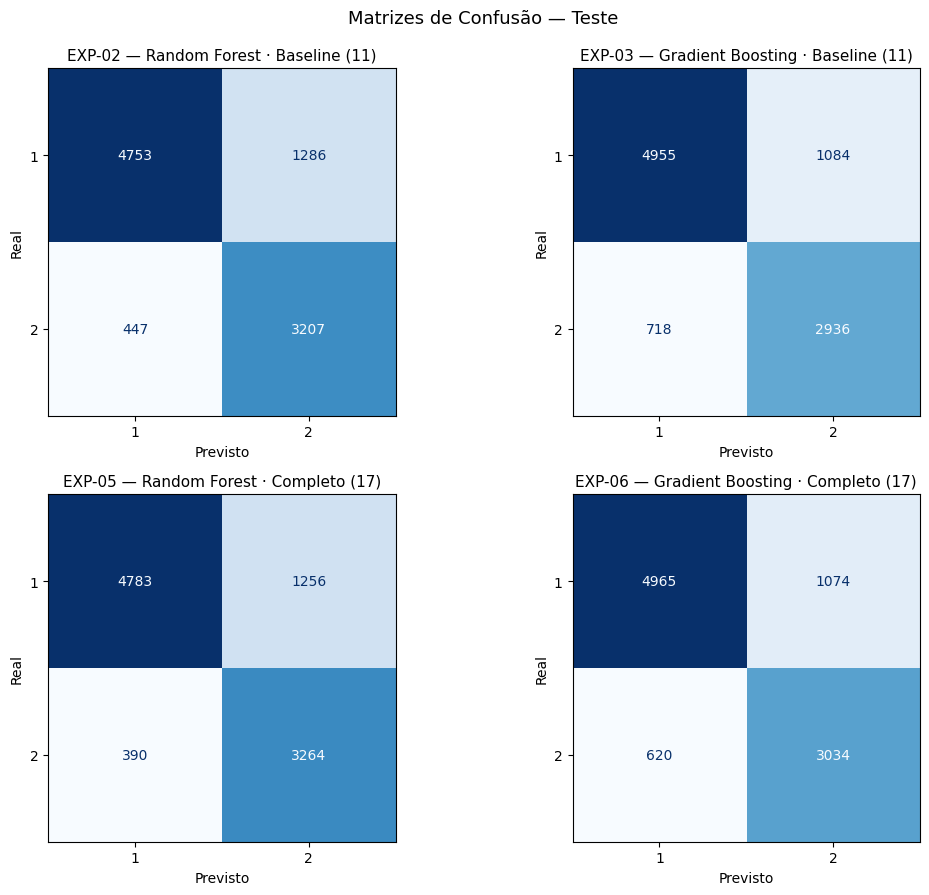

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, reg in zip(axes.ravel(), resultados):
    disp = ConfusionMatrixDisplay(reg["_cm_teste"], display_labels=[1, 2])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{reg['exp_id']} — {reg['modelo']} · {reg['conjunto']}",
                 fontsize=11)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
for ax in axes.ravel()[len(resultados):]:
    ax.axis("off")
fig.suptitle("Matrizes de Confusão — Teste", fontsize=13, y=0.99)
fig.tight_layout()
plt.show()

## 9. Impacto da engenharia de atributos (Baseline × Completo)

Comparação direta entre o Conjunto A (Baseline) e o Conjunto B (Completo) para cada
modelo de árvore, no conjunto de teste. É o teste da hipótese central do DoE: *as
features de engenharia agregam ganho preditivo?*


teste_f1_macro               teste_roc_auc              
conjunto           Baseline (11) Completo (17) Baseline (11) Completo (17)
modelo                                                                    
Gradient Boosting         0.8057        0.8180        0.8989        0.9034
Random Forest             0.8165        0.8259        0.9038        0.9089

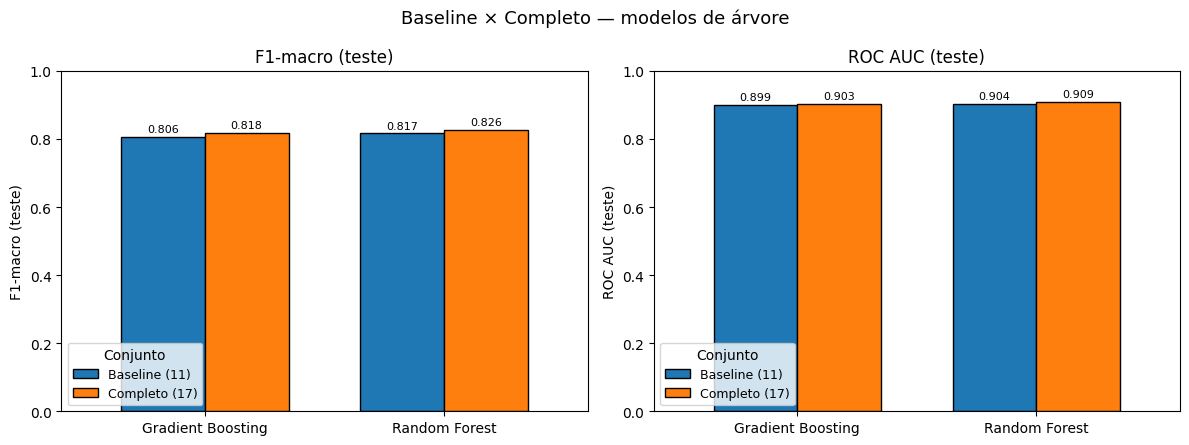

In [14]:
comp = res_df.pivot_table(index="modelo", columns="conjunto",
                          values=["teste_f1_macro", "teste_roc_auc"])
comp = comp.round(4)
display(comp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metrica, titulo in zip(
        axes, ["teste_f1_macro", "teste_roc_auc"], ["F1-macro (teste)", "ROC AUC (teste)"]):
    sub = res_df.pivot_table(index="modelo", columns="conjunto", values=metrica)
    sub = sub[[c for c in ["Baseline (11)", "Completo (17)"] if c in sub.columns]]
    sub.plot(kind="bar", ax=ax, rot=0, edgecolor="black", width=0.7)
    ax.set_title(titulo)
    ax.set_ylabel(titulo)
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.legend(title="Conjunto", fontsize=9)
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.3f", fontsize=8, padding=2)
fig.suptitle("Baseline × Completo — modelos de árvore", fontsize=13)
fig.tight_layout()
plt.show()

In [15]:
# Seleção do melhor experimento de árvore pela média de f1_macro na CV
melhor = res_df.sort_values(
    ["cv_f1_macro_mean", "cv_f1_macro_std"], ascending=[False, True]).iloc[0]
print("Melhor experimento de árvore (critério do DoE: maior f1_macro na CV):")
print(f"  {melhor['exp_id']} — {melhor['modelo']} · {melhor['conjunto']}")
print(f"  f1_macro (CV)  = {melhor['cv_f1_macro_mean']:.4f} ± {melhor['cv_f1_macro_std']:.4f}")
print(f"  f1_macro (teste) = {melhor['teste_f1_macro']:.4f}")
print(f"  ROC AUC (teste)  = {melhor['teste_roc_auc']:.4f}")
print(f"  Hiperparâmetros: {melhor['melhores_hiperparametros']}")

Melhor experimento de árvore (critério do DoE: maior f1_macro na CV):
  EXP-05 — Random Forest · Completo (17)
  f1_macro (CV)  = 0.8193 ± 0.0046
  f1_macro (teste) = 0.8259
  ROC AUC (teste)  = 0.9089
  Hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None, 'class_weight': 'balanced'}


## 9.4 Persistência de artefatos (para o relatório e a validação)

Exporta os artefatos consumidos pelo relatório explicativo e pela etapa de validação
(notebook 06):

- `outputs/cv_results_EXP-0X.csv` — **todas** as configurações sorteadas em cada busca
  (mapa hiperparâmetro → resultado: `mean_test_*`, `std_test_*`, `mean_train_*`,
  `rank_test_*`), ordenadas por `rank_test_f1_macro`.
- `outputs/resumo_experimentos_arvores.csv` — uma linha por experimento (CV + treino +
  teste + melhores hiperparâmetros).
- `outputs/models/{EXP}_{modelo}.joblib` — Pipelines completos treinados
  (pré-processamento + modelo), reusados na validação sem re-treino.

> Os artefatos refletem o `MODO_RAPIDO` em vigor (registrado na coluna `modo_rapido` do
> resumo). Com `MODO_RAPIDO = True`, os hiperparâmetros vêm de um espaço de busca
> reduzido — são de demonstração, não os oficiais da Tabela 1 do PDF.


In [16]:
import joblib

# Diretório outputs/ (reaproveita o caminho já localizado no carregamento dos dados).
OUTPUTS_DIR = train_path.parent if train_path is not None else Path("outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = OUTPUTS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ---- (a) Ranking completo por experimento: mapa hiperparâmetro -> resultado ----
for reg in resultados:
    cvr = pd.DataFrame(reg["_cv_results"])
    cols = (["params"]
            + [c for c in cvr.columns
               if c.startswith(("mean_test_", "std_test_", "mean_train_", "rank_test_"))])
    ranking = (cvr[cols]
               .sort_values("rank_test_f1_macro")
               .reset_index(drop=True))
    ranking["params"] = ranking["params"].astype(str)
    destino = OUTPUTS_DIR / f"cv_results_{reg['exp_id']}.csv"
    ranking.to_csv(destino, index=False)
    print(f"[{reg['exp_id']}] {len(ranking)} configs -> {destino}")

# ---- (b) Tabela-resumo consolidada (uma linha por experimento) ----
colunas_resumo = [
    "exp_id", "conjunto", "modelo", "melhores_hiperparametros",
    "cv_f1_macro_mean", "cv_f1_macro_std", "cv_roc_auc_mean", "cv_roc_auc_std",
    "treino_f1_macro",
    "teste_accuracy", "teste_balanced_accuracy",
    "teste_precision_pos", "teste_recall_pos", "teste_f1_pos",
    "teste_precision_macro", "teste_recall_macro", "teste_f1_macro",
    "teste_roc_auc",
]
resumo_exp = res_df[colunas_resumo].copy()
resumo_exp["melhores_hiperparametros"] = resumo_exp["melhores_hiperparametros"].astype(str)
resumo_exp["modo_rapido"] = MODO_RAPIDO
resumo_path = OUTPUTS_DIR / "resumo_experimentos_arvores.csv"
resumo_exp.to_csv(resumo_path, index=False)
print("Resumo salvo em:", resumo_path)

# ---- (c) Persistência dos Pipelines treinados (pré-processamento + modelo) ----
for reg in resultados:
    slug = reg["modelo"].lower().replace(" ", "_")
    destino = MODELS_DIR / f"{reg['exp_id']}_{slug}.joblib"
    joblib.dump(reg["_estimator"], destino)
    print(f"[{reg['exp_id']}] modelo salvo -> {destino}")
print("\nArtefatos persistidos em:", OUTPUTS_DIR)

[EXP-02] 6 configs -> /home/jovi/src2/datamining-project-unifei/outputs/cv_results_EXP-02.csv
[EXP-03] 4 configs -> /home/jovi/src2/datamining-project-unifei/outputs/cv_results_EXP-03.csv
[EXP-05] 6 configs -> /home/jovi/src2/datamining-project-unifei/outputs/cv_results_EXP-05.csv
[EXP-06] 4 configs -> /home/jovi/src2/datamining-project-unifei/outputs/cv_results_EXP-06.csv
Resumo salvo em: /home/jovi/src2/datamining-project-unifei/outputs/resumo_experimentos_arvores.csv
[EXP-02] modelo salvo -> /home/jovi/src2/datamining-project-unifei/outputs/models/EXP-02_random_forest.joblib
[EXP-03] modelo salvo -> /home/jovi/src2/datamining-project-unifei/outputs/models/EXP-03_gradient_boosting.joblib


[EXP-05] modelo salvo -> /home/jovi/src2/datamining-project-unifei/outputs/models/EXP-05_random_forest.joblib
[EXP-06] modelo salvo -> /home/jovi/src2/datamining-project-unifei/outputs/models/EXP-06_gradient_boosting.joblib

Artefatos persistidos em: /home/jovi/src2/datamining-project-unifei/outputs


## 10. Regressão Logística (EXP-01 e EXP-04) — adiada

A execução da **Regressão Logística** (`GridSearchCV`, EXP-01 e EXP-04) ficou **fora
desta etapa** e será realizada posteriormente, em conjunto com a comparação final
contra os modelos de árvore. O código de busca foi **removido deste notebook** para
mantê-lo focado nos modelos de árvore.

A discussão *saída categórica × saída contínua* já está na **Seção 5** e se aplica
igualmente à Regressão Logística (que é um **classificador**): probabilidade contínua
via `predict_proba` e rótulo categórico via `predict` — a mesma função `avaliar(...)`
e o mesmo `scoring` valem sem mudanças.

Grade prevista no PDF (Tabela 1), para referência: `penalty ∈ {l1, l2}`,
`C ∈ {0.01, 0.1, 1, 10}`, `solver = liblinear`, `class_weight ∈ {balanced, None}`.


## 11. Conclusões e critério de seleção final

- Os quatro experimentos de árvore (EXP-02, EXP-03, EXP-05, EXP-06) foram executados
  com `RandomizedSearchCV`, `StratifiedKFold`, `refit='f1_macro'` e
  `random_state=42`, exatamente como no DoE.
- As métricas seguem o PDF e respeitam a forma de saída correta: **rótulos** para
  Acurácia/Precisão/Recall/F1/Matriz de Confusão e **probabilidade** para ROC AUC,
  reportadas em **treino e teste**.
- A comparação **Baseline × Completo** quantifica o ganho da engenharia de atributos.
- A Seção 9.4 persistiu os artefatos (`cv_results_EXP-0X.csv`,
  `resumo_experimentos_arvores.csv`, `models/*.joblib`) para o relatório e a validação.

**Critério de seleção final (do DoE):** maior média de `f1_macro` na validação
cruzada; em caso de empate prático, menor variância em `f1_macro`, maior
`balanced_accuracy`, menor complexidade e desempenho consistente no teste.

**Próximos passos:**
1. **Validação contra dados nunca vistos** (`validation/*.json`) — notebook
   `06_validacao_entrega3.ipynb`, que reusa os modelos `.joblib` e mede a generalização.
2. Executar EXP-01 e EXP-04 (Regressão Logística, `GridSearchCV`) e comparar com os
   modelos de árvore na tabela consolidada.

---
> **Lembrete:** se a célula de carregamento indicou fonte **SINTÉTICA**, os números
> acima são apenas de demonstração. Coloque `drug_events_train_transformed.csv` e
> `drug_events_test_transformed.csv` (Entrega 2) em `outputs/` e reexecute o notebook
> para obter os resultados reais.
